<font size="5"><center>Taller de procesamiento de señales

<font size="5">Ejercicio obligatorio SVM

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445

In [1]:
!wget https://github.com/mvera1412/TA136-TB056-TB057-8625/raw/refs/heads/main/data/ejs_svm.pkl

--2025-10-10 11:58:40--  https://github.com/mvera1412/TA136-TB056-TB057-8625/raw/refs/heads/main/data/ejs_svm.pkl
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/ejs_svm.pkl [following]
--2025-10-10 11:58:40--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/ejs_svm.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15882 (16K) [application/octet-stream]
Saving to: ‘ejs_svm.pkl’

ejs_svm.pkl         100%[===================>]  15.51K  --.-KB/s    in 0s      

2025-10-10 11:58:40 (85.4 MB/s) - ‘ejs_svm.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk

In [32]:
data = pd.read_pickle('ejs_svm.pkl') #diccionariio
display(data.keys())
data = data['2do Dataset']
print(data.keys())
X = data['X']
y = data['y']
print(type(X), X.shape)
print(type(y), y.shape)
print(np.unique(y)) #y puede ser 0 o 1
y = y.flatten()
print(type(y), y.shape)

dict_keys(['1er Dataset', '2do Dataset'])

dict_keys(['X', 'y'])
<class 'numpy.ndarray'> (863, 2)
<class 'numpy.ndarray'> (863, 1)
[0 1]
<class 'numpy.ndarray'> (863,)


#a)
Implementar una clasificación SVM con Kernel gaussiano (γ = 50) utilizando svm.SVC (sklearn) con
C = 1.

In [33]:
SVM = sk.svm.SVC(kernel = 'rbf', gamma = 50, C = 1)
SVM.fit(X, y)

SVC(C=1, gamma=50)

#b)
Graficar la frontera de decisión y las curvas de vectores soportes sobre un scatter

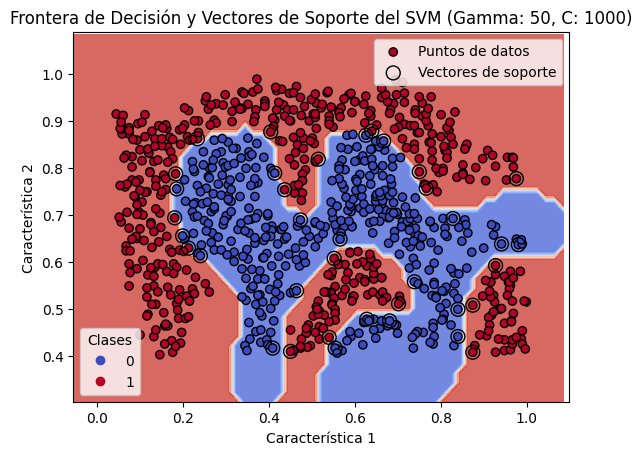

In [49]:
def graficar(SVM, X, y):
  e = 0.1
  x_min, x_max = X[:, 0].min() - e, X[:, 0].max() + e
  y_min, y_max = X[:, 1].min() - e, X[:, 1].max() + e
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

  Z = SVM.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

  scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', label='Puntos de datos')

  plt.scatter(SVM.support_vectors_[:, 0], SVM.support_vectors_[:, 1], s=100,
              facecolors='none', edgecolors='k', label='Vectores de soporte')

  plt.xlabel('Característica 1')
  plt.xlim(x_min, x_max)
  plt.ylim(y_min, y_max)
  plt.ylabel('Característica 2')
  plt.title(f'Frontera de Decisión y Vectores de Soporte del SVM (Gamma: {SVM.gamma}, C: {SVM.C})')

  legend1 = plt.legend(*scatter.legend_elements(), loc="lower left", title="Clases")
  plt.gca().add_artist(legend1)

  plt.legend(loc="upper right")


  plt.show()

graficar(SVM, X, y)

#c)
Repetir para diferentes valores de C. Extraer conclusiones.

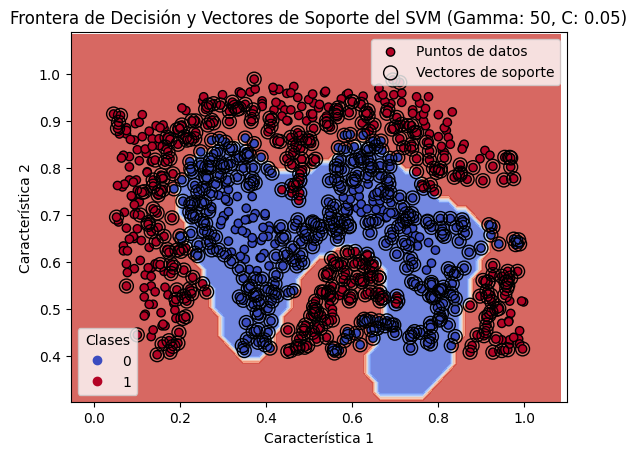

0.9246813441483198


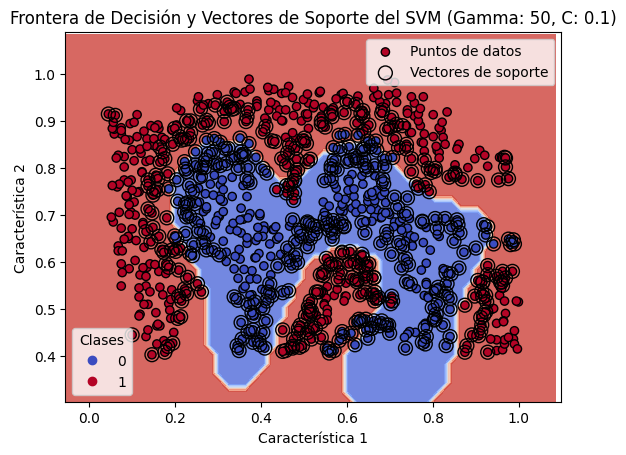

0.9501738122827347


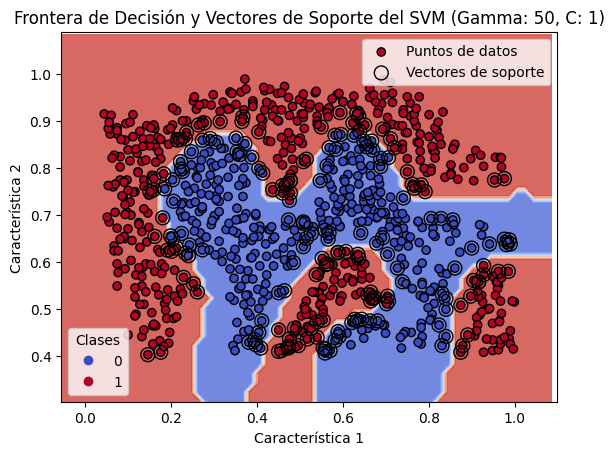

0.9895712630359212


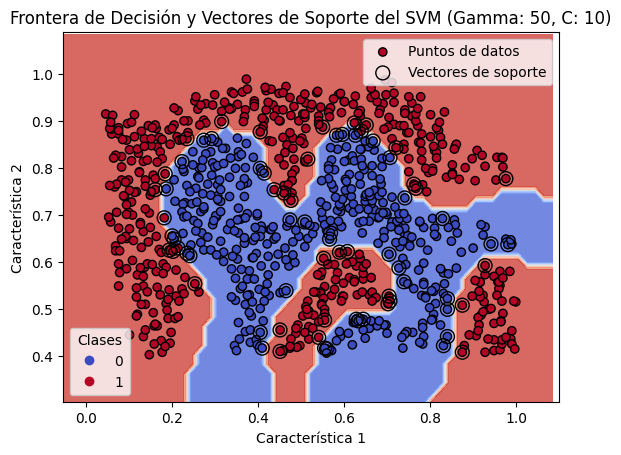

0.996523754345307


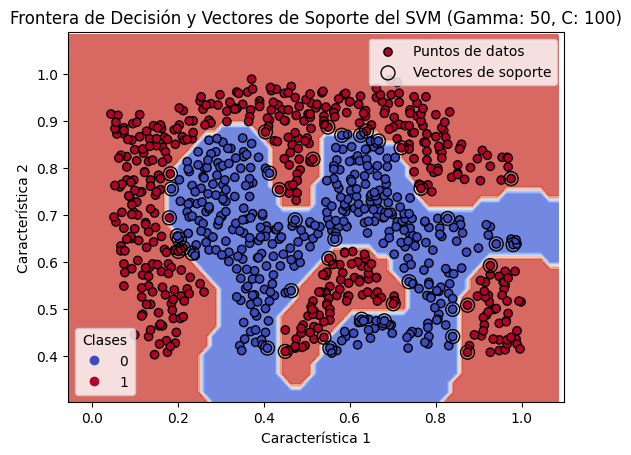

0.9976825028968713


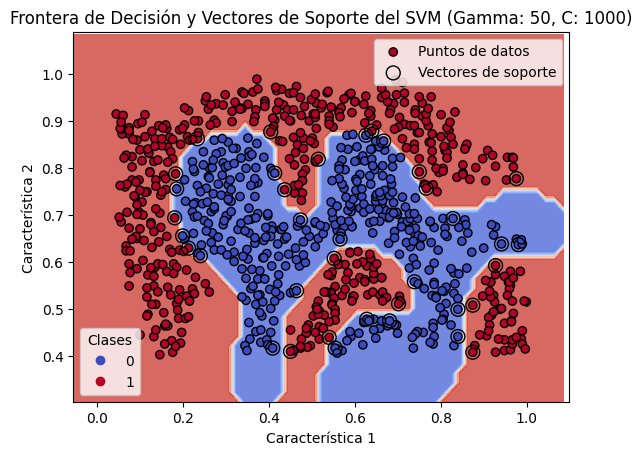

1.0


In [62]:
C_list = [0.05, 0.1, 1, 10, 100, 1000]

for C in C_list:
  SVM = sk.svm.SVC(kernel = 'rbf', gamma = 50, C = C)
  SVM.fit(X, y)
  graficar(SVM, X, y)
  print(SVM.score(X, y))

## Conclusiones:
El algoritmo busca resolver la siguiente minimización
$$
\min_{w, b, \xi} \ \frac{1}{2} \|w\|^2 + C \sum_i \xi_i
$$
sujeto a:
$$
y_i (w \cdot x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0
$$

Los términos $\xi_i$ representan penalizaciones para cada punto que cae dentro del margen. Para valores chicos de C estas penalizaciones pesan poco. Eso genera que algunos puntos sean mal clasificados. Se observa en que el accuracy de entrenamiento es bajo. El algoritmo está subajustado.

Valores grandes de C penalizan mucho estos errores. Eso provoca que el margen sea más angosto, lo que mejora el accuracy de entrenamiento. Sin embargo, el algoritmo está sobreajustado. Si hubiera un conjunto de testeo se observaría un mal desempeño.

Entonces, el parámetro C regula el compromiso entre la complejidad y la capacidad de generalización del algoritmo

(d)
Repetir para diferentes valores de γ. Extraer conclusiones

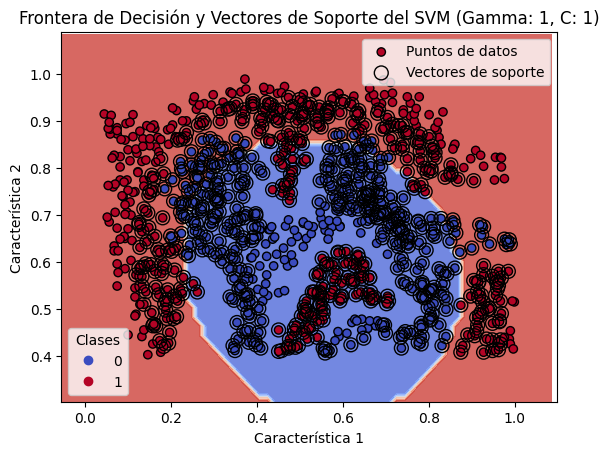

0.8088064889918888


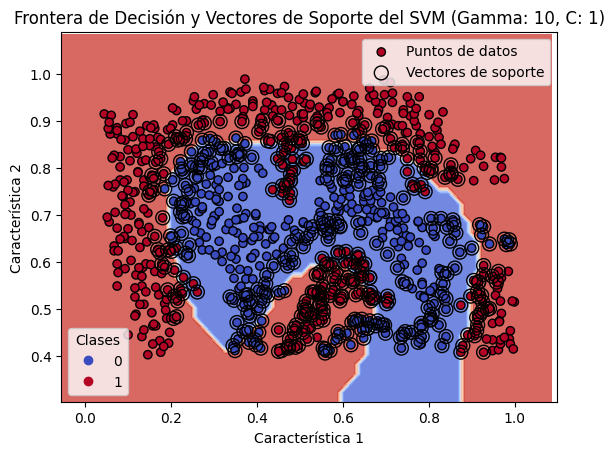

0.884125144843569


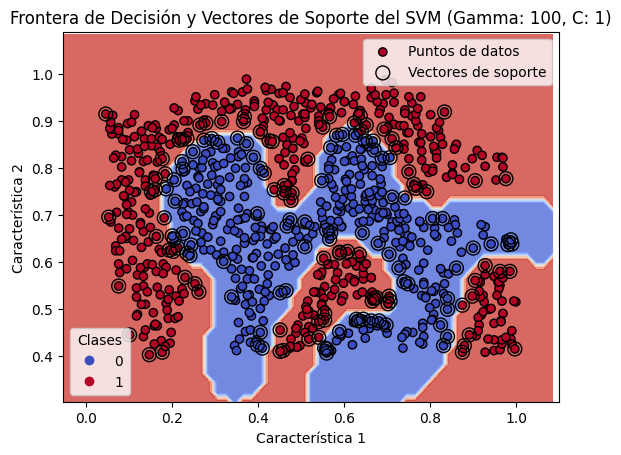

0.9976825028968713


In [56]:
gama_list = [1, 10, 100]

for gama in gama_list:
  SVM = sk.svm.SVC(kernel = 'rbf', gamma = gama, C = 1)
  SVM.fit(X, y)
  graficar(SVM, X, y)
  print(SVM.score(X, y))

El kernel del algoritmo permite generar fronteras de decisión no lineales. El kernel

$$
K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)
$$

representa un producto interno entre los datos $x_i$ y $x_j$ en un espacio de mayor dimensión que el original. Representa qué tanto se parecen $x_i$ y $x_j$.

En el kernel gaussiano

$$
K(x_i, x_j) = e^{-\gamma||x_i - x_j||^2}
$$

la constante γ representa la velocidad de decrecimiento. Para valores chicos de gamma $K$ toma un valor alto aunque $x_i$ y $x_j$ estén lejos. Para valores grandes el decaimiento es rápido.

El kernel se utiliza para medir la similitud entre un dato y los vectores soporte.

Eso influye en el algoritmo de la siguiente manera: para valores chicos de $\gamma$ la influencia de los vectores soporte llegará más lejos. Eso produce márgenes más amplios y subajuste. Para valores grandes de γ la influencia de los vectores soporte se limita al entorno cercano, produciendo márgenes angostos. En el caso extremo, el algoritmo quedará sobreajustado.

En resumen, ambos parámetros C y γ permiten regular el compromiso entre generalidad y sobreajuste.